In [ ]:
import os
import glob

import numpy as np
import pandas as pd

# Tự phát hiện đường dẫn dữ liệu trong workspace hoặc Kaggle
candidate_dirs = [
    '/workspaces/SGU2627K1_MAYHOC/Tuan02/Data',
    os.path.join(os.getcwd(), 'Tuan02', 'Data'),
    os.path.join(os.getcwd(), 'Data'),
    '/kaggle/input/competitions/house-prices-advanced-regression-techniques',
]

train_path = None
test_path = None

for d in candidate_dirs:
    if not os.path.isdir(d):
        continue
    train_matches = sorted(glob.glob(os.path.join(d, 'train*.csv')))
    test_matches = sorted(glob.glob(os.path.join(d, 'test*.csv')))
    if train_matches:
        train_path = train_matches[0]
    if test_matches:
        test_path = test_matches[0]
    if train_path and test_path:
        break

if not train_path or not test_path:
    raise FileNotFoundError('Không tìm thấy train.csv/test.csv. Kiểm tra thư mục dữ liệu.')

print('Train path:', train_path)
print('Test path:', test_path)


ModuleNotFoundError: No module named 'numpy'

# Bước 1 - Business Understanding + Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


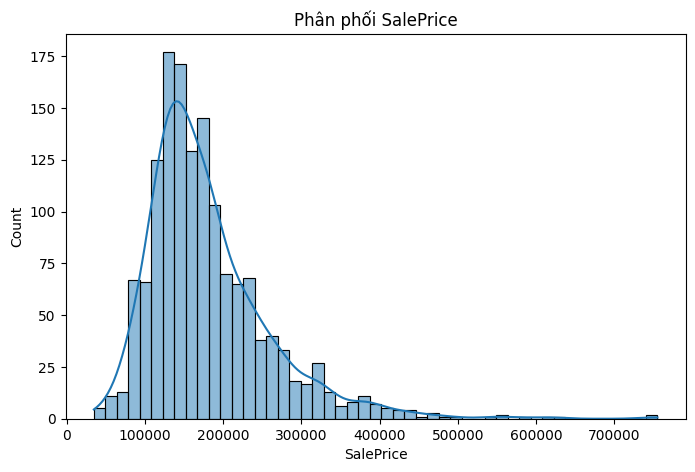

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True)
plt.title('Phân phối SalePrice')
plt.show()

print("Skewness:", train['SalePrice'].skew())
print("Kurtosis:", train['SalePrice'].kurt())

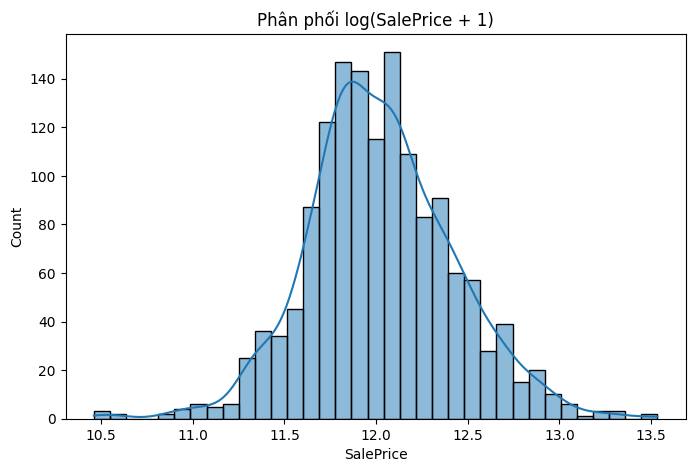

Skewness sau log: 0.12134661989685333


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(train['SalePrice']), kde=True)
plt.title('Phân phối log(SalePrice + 1)')
plt.show()

print("Skewness sau log:", np.log1p(train['SalePrice']).skew())

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


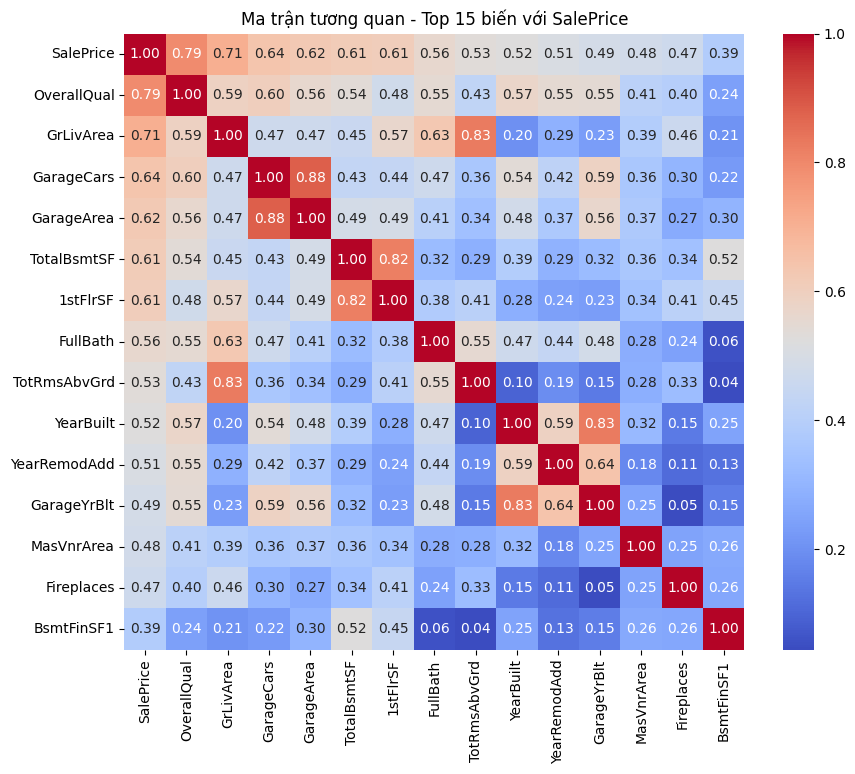

In [ ]:
corr = train.corr(numeric_only=True)
top_corr = corr['SalePrice'].sort_values(ascending=False).head(15)
print(top_corr)

plt.figure(figsize=(10,8))
sns.heatmap(train[top_corr.index].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Ma trận tương quan - Top 15 biến với SalePrice')
plt.show()

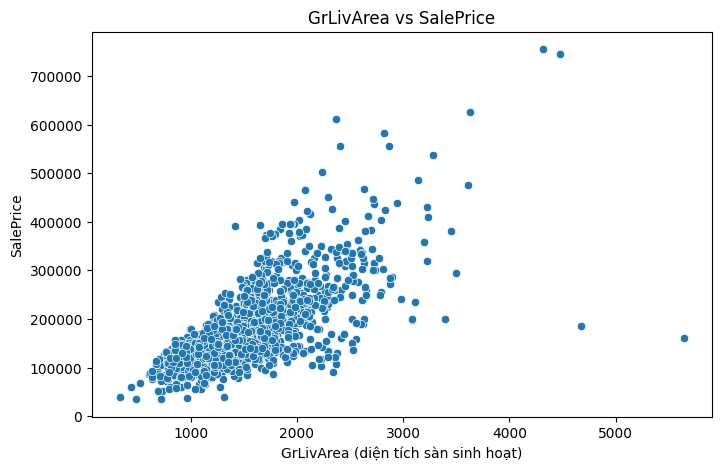

        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000


In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title('GrLivArea vs SalePrice')
plt.xlabel('GrLivArea (diện tích sàn sinh hoạt)')
plt.ylabel('SalePrice')
plt.show()

outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(outliers[['Id', 'GrLivArea', 'SalePrice']])

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


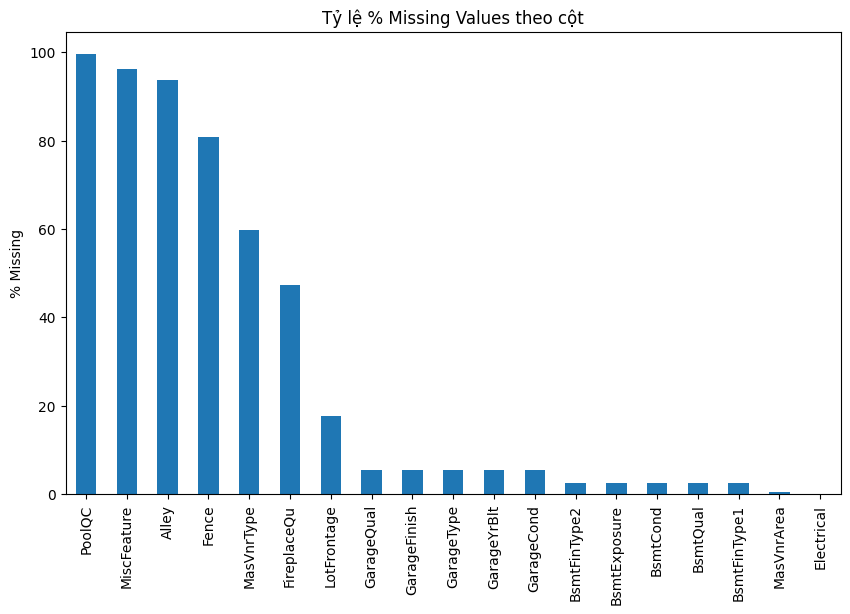

In [ ]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

plt.figure(figsize=(10,6))
missing_pct.plot(kind='bar')
plt.title('Tỷ lệ % Missing Values theo cột')
plt.ylabel('% Missing')
plt.xticks(rotation=90)
plt.show()    

# Bước 2 - Data Preparation


In [ ]:
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)
print("Train shape sau khi loại outliers:", train.shape)

Train shape sau khi loại outliers: (1458, 81)


In [ ]:
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train['SalePrice'].values

all_data = pd.concat([train.drop('SalePrice', axis=1), test]).reset_index(drop=True)
print("all_data shape:", all_data.shape)

all_data shape: (2917, 80)


In [ ]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in cols_none:
    all_data[col] = all_data[col].fillna('None')

In [ ]:
cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in cols_zero:
    all_data[col] = all_data[col].fillna(0)

In [ ]:
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
cols_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']

for col in cols_mode:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

In [ ]:
print(all_data['Utilities'].value_counts())

Utilities
AllPub    2914
NoSeWa       1
Name: count, dtype: int64


In [ ]:
missing_check = all_data.isnull().sum()
missing_check = missing_check[missing_check > 0]
print("Số cột còn thiếu dữ liệu:", len(missing_check))
print(missing_check)

Số cột còn thiếu dữ liệu: 1
Utilities    2
dtype: int64


In [ ]:
all_data = all_data.drop(['Utilities'], axis=1)

missing_check = all_data.isnull().sum()
missing_check = missing_check[missing_check > 0]
print("Số cột còn thiếu dữ liệu:", len(missing_check))

Số cột còn thiếu dữ liệu: 0


In [ ]:
# Tổng diện tích sàn (tầng hầm + tầng 1 + tầng 2)
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Tuổi nhà tại thời điểm bán
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

# Số năm kể từ lần sửa chữa gần nhất đến khi bán
all_data['YearsSinceRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']

# Tổng số phòng tắm (full tính 1, half tính 0.5)
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                          all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

# Tổng diện tích hiên/sân (porch)
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                             all_data['3SsnPorch'] + all_data['ScreenPorch'])

# Biến nhị phân: có/không có các đặc điểm
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print("Số cột sau khi thêm feature mới:", all_data.shape[1])

Số cột sau khi thêm feature mới: 89


In [ ]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map)

# Một số biến ordinal khác có thang đo riêng
bsmt_exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(bsmt_exposure_map)

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map)

garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
all_data['GarageFinish'] = all_data['GarageFinish'].map(garage_finish_map)

print("Đã encode xong các biến ordinal")

Đã encode xong các biến ordinal


In [ ]:
print("Số cột trước One-Hot:", all_data.shape[1])

all_data = pd.get_dummies(all_data, drop_first=True)

print("Số cột sau One-Hot:", all_data.shape[1])

Số cột trước One-Hot: 89
Số cột sau One-Hot: 225


In [ ]:
from scipy.stats import skew

numeric_feats = all_data.dtypes[all_data.dtypes != 'bool'].index
numeric_feats = [c for c in numeric_feats if all_data[c].dtype in ['int64', 'float64']]

skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = skewed_feats[abs(skewed_feats) > 0.75]

print("Số biến bị lệch mạnh (skew > 0.75):", skewness.shape[0])
print(skewness.head(15))

Số biến bị lệch mạnh (skew > 0.75): 34
MiscVal          21.939672
PoolArea         17.688664
HasPool          15.494756
LotArea          13.109495
LowQualFinSF     12.084539
3SsnPorch        11.372080
KitchenAbvGr      4.300550
BsmtFinSF2        4.144503
EnclosedPorch     4.002344
ScreenPorch       3.945101
BsmtHalfBath      3.929996
BsmtFinType2      3.150951
MasVnrArea        2.621719
OpenPorchSF       2.529358
TotalPorchSF      2.244500
dtype: float64


In [ ]:
skewed_features = skewness.index
for feat in skewed_features:
    all_data[feat] = np.log1p(all_data[feat])

print("Đã log-transform xong", len(skewed_features), "biến")

Đã log-transform xong 34 biến


In [ ]:
y_train = np.log1p(y_train)
print("Đã log-transform SalePrice")

Đã log-transform SalePrice


In [ ]:
train_processed = all_data[:ntrain]
test_processed = all_data[ntrain:]

print("Train processed shape:", train_processed.shape)
print("Test processed shape:", test_processed.shape)

Train processed shape: (1458, 225)
Test processed shape: (1459, 225)


# Bước 3 - Modeling

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

X_train = train_processed.values
X_test = test_processed.values

n_folds = 5

def rmse_cv(model):
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X_train, y_train, 
                                      scoring='neg_mean_squared_error', cv=kf))
    return rmse

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import RobustScaler

# Chuẩn hóa dữ liệu trước khi đưa vào mô hình tuyến tính
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def rmse_cv(model, X):
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X, y_train, 
                                      scoring='neg_mean_squared_error', cv=kf))
    return rmse

lr = LinearRegression()
ridge = Ridge(alpha=10)
lasso = Lasso(alpha=0.001, max_iter=50000)

score_lr = rmse_cv(lr, X_train_scaled)
score_ridge = rmse_cv(ridge, X_train_scaled)
score_lasso = rmse_cv(lasso, X_train_scaled)

print(f"Linear Regression: {score_lr.mean():.5f} (+/- {score_lr.std():.5f})")
print(f"Ridge:              {score_ridge.mean():.5f} (+/- {score_ridge.std():.5f})")
print(f"Lasso:              {score_lasso.mean():.5f} (+/- {score_lasso.std():.5f})")

Linear Regression: 0.12807 (+/- 0.01175)
Ridge:              0.11420 (+/- 0.00834)
Lasso:              0.11537 (+/- 0.00794)


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42, n_jobs=-1)

# Mô hình cây không cần scale dữ liệu, dùng X_train gốc
score_rf = rmse_cv(rf, X_train)
score_gbr = rmse_cv(gbr, X_train)
score_xgb = rmse_cv(xgb, X_train)

print(f"Random Forest:      {score_rf.mean():.5f} (+/- {score_rf.std():.5f})")
print(f"Gradient Boosting:  {score_gbr.mean():.5f} (+/- {score_gbr.std():.5f})")
print(f"XGBoost:            {score_xgb.mean():.5f} (+/- {score_xgb.std():.5f})")

Random Forest:      0.13698 (+/- 0.00664)
Gradient Boosting:  0.12490 (+/- 0.00504)
XGBoost:            0.12339 (+/- 0.00737)


In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_params = {'alpha': [0.1, 1, 5, 10, 15, 20, 30, 50, 75, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, scoring='neg_mean_squared_error', cv=5)
ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha (Ridge):", ridge_grid.best_params_)
print("Best RMSE (Ridge):", np.sqrt(-ridge_grid.best_score_))

Best alpha (Ridge): {'alpha': 10}
Best RMSE (Ridge): 0.11451195671245284


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': [300, 500, 800],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_params, n_iter=30, scoring='neg_mean_squared_error', 
    cv=5, random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("Best params (XGBoost):", xgb_search.best_params_)
print("Best RMSE (XGBoost):", np.sqrt(-xgb_search.best_score_))

Best params (XGBoost): {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best RMSE (XGBoost): 0.11746284632912428


In [ ]:
final_model = Ridge(alpha=10)
final_model.fit(X_train_scaled, y_train)

train_pred = final_model.predict(X_train_scaled)
train_rmse = np.sqrt(np.mean((train_pred - y_train)**2))
print("RMSE trên tập train (final model):", train_rmse)

RMSE trên tập train (final model): 0.0995858636034066


# Bước 4 - Evaluation

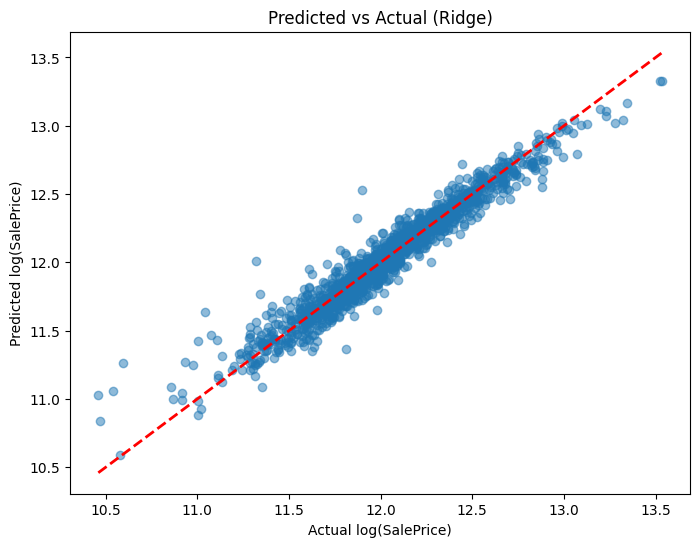

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_train, train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('Predicted vs Actual (Ridge)')
plt.show()

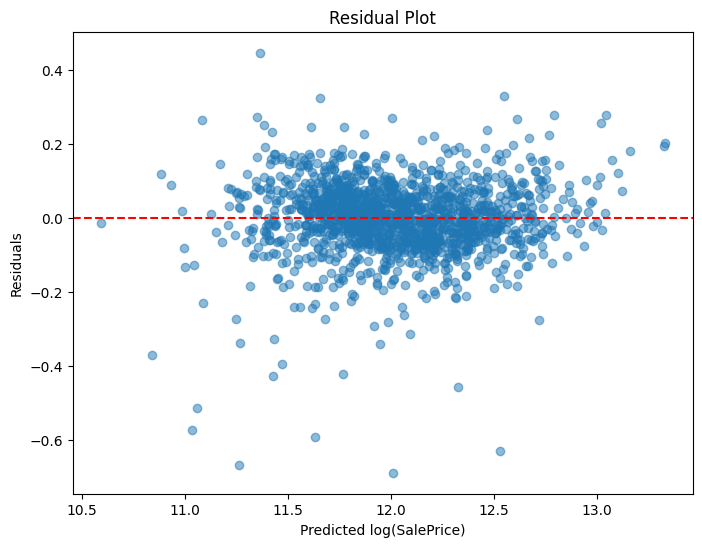

In [ ]:
residuals = y_train - train_pred

plt.figure(figsize=(8,6))
plt.scatter(train_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log(SalePrice)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

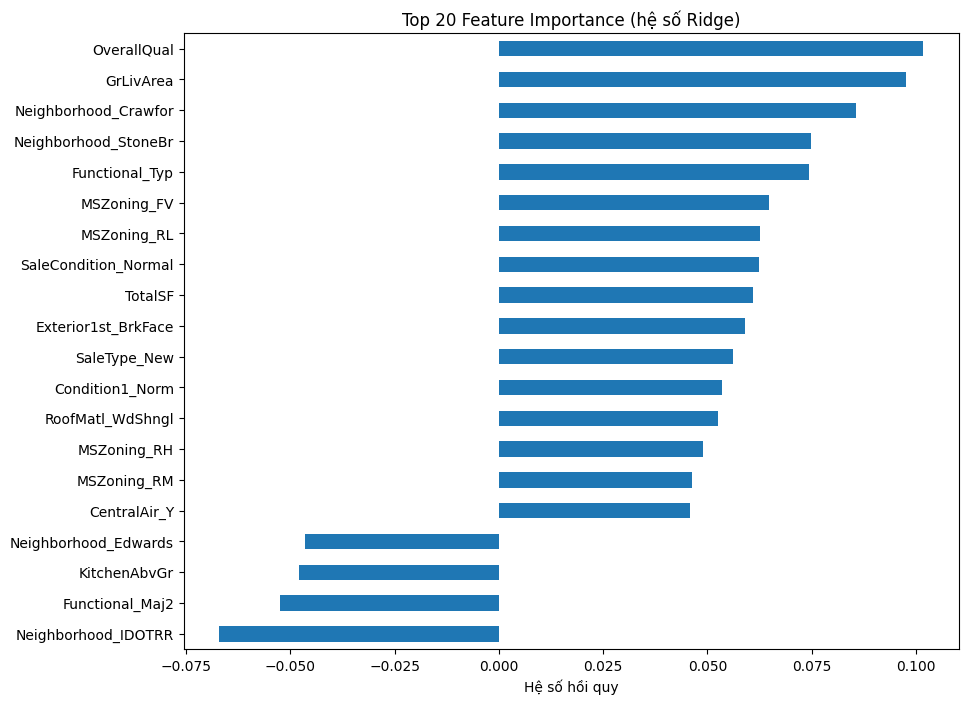

In [ ]:
feature_importance = pd.Series(final_model.coef_, index=train_processed.columns)
top_features = feature_importance.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))
feature_importance[top_features.index].sort_values().plot(kind='barh')
plt.title('Top 20 Feature Importance (hệ số Ridge)')
plt.xlabel('Hệ số hồi quy')
plt.show()

# Bước 5 - Deployment

In [ ]:
X_test_scaled_final = scaler.transform(test_processed.values)
test_pred_log = final_model.predict(X_test_scaled_final)

# Chuyển ngược log về giá trị gốc - QUAN TRỌNG, đừng bỏ qua bước này
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_pred
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print("Đã xuất file submission.csv, shape:", submission.shape)

     Id      SalePrice
0  1461  115706.794847
1  1462  154013.326080
2  1463  181196.580680
3  1464  197059.773946
4  1465  196850.135340
Đã xuất file submission.csv, shape: (1459, 2)
